# Spatially allocating a `ws3` harvest schedule to raster grids

This tutorial demonstrates how to take an aspatial harvest schedule produced by `ws3`, disaggregate it to annual steps, and allocate it across a rasterized forest inventory using the [`ws3.spatial.ForestRaster`](https://ws3.readthedocs.io/en/latest/api.html#ws3.spatial.ForestRaster) class. The workflow mirrors the spatial allocation utilities used by `spades_ws3`, but keeps things self-contained inside this repository.

We will:

- build a `ForestModel` from the sample Woodstock-format files
- generate a quick heuristic harvest schedule
- rasterize the sample stand inventory shapefile to a three-band GeoTIFF (hash, age, block id)
- use `ForestRaster` to convert the 10-year schedule into annual GeoTIFF disturbance maps
- inspect the resulting rasters and summarise disturbed area per year


## Recommended environment

As with the other notebooks in this folder, running inside a sandboxed virtual environment keeps dependencies tidy (see `000_venv_python_kernel_setup.ipynb`). The commands below assume this notebook lives inside the WS3 repository checkout.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
clobber_ws3 = False
if clobber_ws3:
    %pip uninstall -y ws3
    %pip install -e ..


In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

# allow notebooks to reuse helper utilities in this folder
EXAMPLES_DIR = Path.cwd() / 'examples'
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

import ws3.forest
from ws3.common import rasterize_stands, hash_dt
from ws3.spatial import ForestRaster
from util import schedule_harvest_areacontrol, compile_scenario, plot_scenario


## Data paths

We re-use the sample TSA 24 dataset bundled with the repository. The Woodstock formatted files feed the forest model, while the companion shapefile provides a spatial inventory for rasterization.

In [4]:
#DATA_DIR = Path('examples/data')
DATA_DIR = Path('data')
WOODSTOCK_DIR = DATA_DIR / 'woodstock_model_files_tsa24_clipped'
SHAPE_PATH = DATA_DIR / 'shp' / 'tsa24_clipped.shp' / 'stands.shp'

# output directories (created on demand)
RASTER_DIR = DATA_DIR / 'raster_spatial_demo'
RASTER_DIR.mkdir(parents=True, exist_ok=True)
INVENTORY_TIF = RASTER_DIR / 'tsa24_inventory.tif'

SPATIAL_DIR = DATA_DIR / 'spatial_outputs' / 'tsa24_demo'
SPATIAL_DIR.mkdir(parents=True, exist_ok=True)

INVENTORY_TIF, SPATIAL_DIR


(PosixPath('data/raster_spatial_demo/tsa24_inventory.tif'),
 PosixPath('data/spatial_outputs/tsa24_demo'))

## Build a `ForestModel`

We load the Woodstock-format inputs, initialise state, and keep the horizon short (5 periods of 10 years) so that the spatial allocation step produces a manageable number of rasters.

In [5]:
BASE_YEAR = 2020
HORIZON = 5
PERIOD_LENGTH = 10

fm = ws3.forest.ForestModel(
    model_name='tsa24_clipped',
    model_path=str(WOODSTOCK_DIR),
    base_year=BASE_YEAR,
    horizon=HORIZON,
    period_length=PERIOD_LENGTH,
    max_age=1000,
)

fm.import_landscape_section()
fm.import_areas_section(convert_periods_to_years=period_length)
fm.import_yields_section(convert_periods_to_years=period_length)
fm.import_actions_section(convert_periods_to_years=period_length)
fm.import_transitions_section(convert_periods_to_years=period_length)
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()

fm


## Heuristic harvest schedule

We call the `schedule_harvest_areacontrol` helper (defined in `examples/util.py`) to generate an aspatial schedule. The function compiles the internal `applied_actions` structure, which `ForestRaster` will later consume.

In [6]:
sch = schedule_harvest_areacontrol(fm)
scenario = compile_scenario(fm)
scenario


,period,oha,ohv,ogs
0,1,103.411088,14069.080670,134541.524980
1,2,105.655079,14690.387934,130879.310887
2,3,103.411088,14352.583697,126127.588834
3,4,103.411088,14403.805319,121730.561271
4,5,103.411088,14167.526587,119035.437396


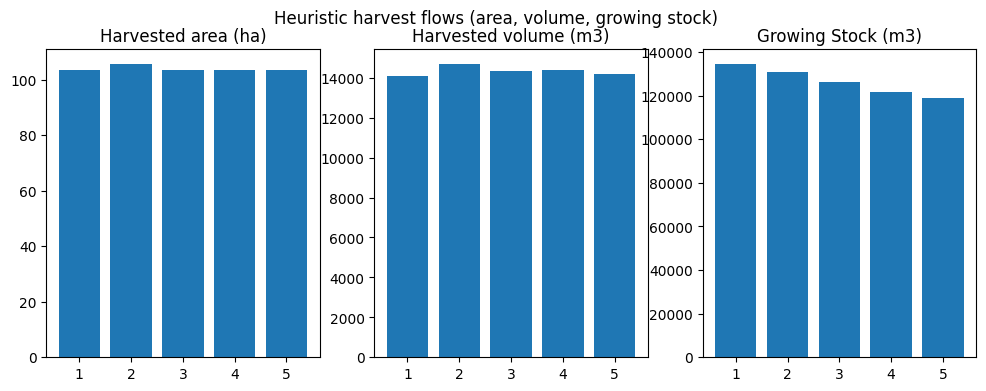

In [7]:
fig, axes = plot_scenario(scenario)
fig.suptitle('Heuristic harvest flows (area, volume, growing stock)')
plt.show()


### Ensure transition lookups cover scheduled ages

Some Woodstock models only declare a generic transition for `age = -1`. The snippet below mirrors what `spades_ws3` does: it copies those generic transitions to every `(action, age)` pair actually referenced in the schedule, so that `ForestRaster` can resolve targets without raising a `KeyError`.

In [8]:
for period in fm.periods:
    for acode, by_dtype in fm.applied_actions[period].items():
        for dtk, by_age in by_dtype.items():
            dt = fm.dtypes[dtk]
            for age in list(by_age.keys()):
                if (acode, age) not in dt.transitions:
                    if (acode, -1) in dt.transitions:
                        dt.transitions[acode, age] = dt.transitions[acode, -1]
                    else:
                        raise KeyError(f"Missing transition for {(acode, age)} in {dtk}")


## Rasterize the stand inventory

`ForestRaster` expects a three-band raster: band 1 stores hashed development type theme values, band 2 stores age (years), and band 3 stores block IDs. The helper `ws3.common.rasterize_stands` creates this raster from the sample shapefile and returns the required hash map.

In [9]:
theme_columns = ['theme0', 'theme1', 'theme2', 'theme3', 'curve1']

hdt_map = rasterize_stands(
    str(SHAPE_PATH),
    str(INVENTORY_TIF),
    theme_cols=theme_columns,
    age_col='age',
    blk_col='curve2',
    age_divisor=1.0,
)

with rasterio.open(INVENTORY_TIF) as src:
    print('Raster shape:', src.count, 'bands', src.width, 'x', src.height)
    print('CRS:', src.crs)
    print('Pixel size:', src.transform.a, 'm')
    print('Hash map entries:', len(hdt_map))


Raster shape: 3 bands 41 x 41
CRS: EPSG:3005
Pixel size: 100.0 m
Hash map entries: 12


## Allocate the schedule to rasters

We instantiate `ForestRaster` with the model, hash metadata, and destination directory. The planner horizon of five periods (10-year periods) becomes 50 annual GeoTIFFs. Each file encodes whether a cell is disturbed (`1`) or untouched (`nodata`/`0`) for the target year.

In [10]:
# clean older outputs from previous runs
for tif in SPATIAL_DIR.glob('harvested_*.tif'):
    tif.unlink()

forest_raster = ForestRaster(
    hdt_map=hdt_map,
    hdt_func=hash_dt,
    src_path=str(INVENTORY_TIF),
    snk_path=str(SPATIAL_DIR),
    acode_map={'harvest': 'harvested'},
    forestmodel=fm,
    base_year=BASE_YEAR,
    horizon=HORIZON,
    period_length=PERIOD_LENGTH,
    time_step=1,
    piggyback_acodes={},
)

forest_raster.allocate_schedule(verbose=False, sda_mode='randblk', nthresh=10)
forest_raster.cleanup()


## Inspect the outputs

The allocation step writes one GeoTIFF per year. Below we list the first few files, visualise the first raster, and summarise the disturbed area (in number of pixels) per year.

In [11]:
output_files = sorted(SPATIAL_DIR.glob('harvested_*.tif'))
output_files[:5]


[PosixPath('data/spatial_outputs/tsa24_demo/harvested_2020.tif'),
 PosixPath('data/spatial_outputs/tsa24_demo/harvested_2021.tif'),
 PosixPath('data/spatial_outputs/tsa24_demo/harvested_2022.tif'),
 PosixPath('data/spatial_outputs/tsa24_demo/harvested_2023.tif'),
 PosixPath('data/spatial_outputs/tsa24_demo/harvested_2024.tif')]

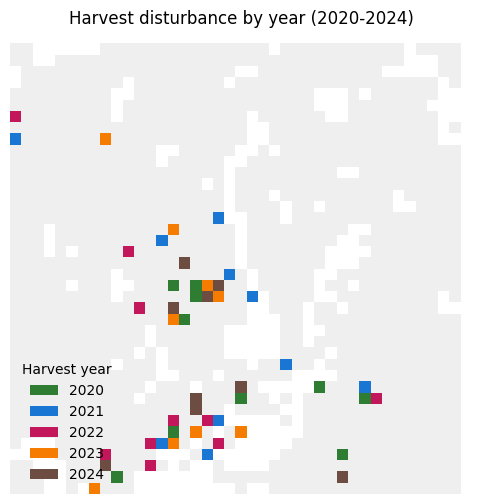

In [12]:
years_to_display = [BASE_YEAR + i for i in range(5)]
files_by_year = {int(path.stem.split('_')[1]): path for path in output_files}
available = [(year, files_by_year[year]) for year in years_to_display if year in files_by_year]

if not available:
    raise ValueError('No harvest rasters found for the requested years.')

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

with rasterio.open(INVENTORY_TIF) as src:
    inventory = src.read(1)
    inv_nodata = src.nodata
    template_shape = inventory.shape
    if inv_nodata is None:
        forest_mask = np.ma.array(np.ones(template_shape, dtype=int), mask=np.isnan(inventory))
    else:
        forest_mask = np.ma.array(np.ones(template_shape, dtype=int), mask=(inventory == inv_nodata))

display = np.full(template_shape, fill_value=-1, dtype=int)

for idx, (year, tif_path) in enumerate(available):
    with rasterio.open(tif_path) as src:
        arr = src.read(1)
        nodata = src.nodata
        if nodata is None:
            harvested = ~np.isnan(arr)
        else:
            harvested = arr != nodata
        display = np.where(harvested, idx, display)

masked_display = np.ma.array(display, mask=display == -1)

color_palette = ['#2E7D32', '#1976D2', '#C2185B', '#F57C00', '#6D4C41'][:len(available)]
harvest_cmap = ListedColormap(color_palette)
norm = BoundaryNorm(range(len(color_palette) + 1), harvest_cmap.N)
background_cmap = ListedColormap(['#e0e0e0'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(forest_mask, cmap=background_cmap, interpolation='nearest', alpha=0.5)
ax.imshow(masked_display, cmap=harvest_cmap, norm=norm, interpolation='nearest')
ax.set_title(f"Harvest disturbance by year ({available[0][0]}-{available[-1][0]})")
ax.axis('off')

handles = [Patch(facecolor=color_palette[i], label=str(year)) for i, (year, _) in enumerate(available)]
ax.legend(handles=handles, title='Harvest year', loc='lower left', frameon=False)
plt.show()


In [13]:
summary = []
for tif in output_files:
    year = int(tif.stem.split('_')[1])
    with rasterio.open(tif) as src:
        arr = src.read(1)
        nodata = src.nodata
        disturbed = np.count_nonzero(arr != nodata)
    summary.append({'year': year, 'disturbed_pixels': disturbed})

pd.DataFrame(summary).head()


,year,disturbed_pixels
0,2020,10
1,2021,10
2,2022,10
3,2023,9
4,2024,9


### Next steps

- Supply your own management-unit mask by passing a tuple (e.g., `('tsa24_clipped', '1', '?', '?', '?')`) to `ForestRaster.allocate_schedule`.
- Use finer time steps (e.g., quarterly) by setting `time_step=0.25` when building `ForestRaster`.
- Combine multiple actions by expanding `acode_map` (each entry gets its own set of year-indexed rasters).

Remember to tidy up raster outputs if the directory should remain clean for version control.